In [101]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, validation_curve, GridSearchCV, cross_val_score, learning_curve
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report,ConfusionMatrixDisplay
import joblib

In [102]:
data = pd.read_csv("donne.csv")

In [103]:
data.head()

,age_months,weight_kg,height_cm,muac_cm,bmi,nutrition_status
0,12.345052,3.000000,54.134002,13.160919,10.0,normal
1,30.807200,5.459076,76.199180,13.944380,10.0,normal
2,15.723226,3.000000,60.280820,13.243565,10.0,normal
3,57.796256,10.103074,104.990471,14.105683,10.0,normal
4,40.321320,7.110583,85.277902,14.641630,10.0,normal


In [104]:
data.shape

(5000, 6)

In [105]:
data.isnull().mean()*100

age_months          0.0
weight_kg           0.0
height_cm           0.0
muac_cm             0.0
bmi                 0.0
nutrition_status    0.0
dtype: float64

In [106]:
data["nutrition_status"].unique()

<ArrowStringArray>
['normal', 'moderate', 'severe']
Length: 3, dtype: str

In [107]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age_months        5000 non-null   float64
 1   weight_kg         5000 non-null   float64
 2   height_cm         5000 non-null   float64
 3   muac_cm           5000 non-null   float64
 4   bmi               5000 non-null   float64
 5   nutrition_status  5000 non-null   str    
dtypes: float64(5), str(1)
memory usage: 265.9 KB


C:\Users\dc\AppData\Local\Temp\ipykernel_21968\4024472635.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = data,  x= "nutrition_status", palette = ["#17F71F21", "#0BACD921", "#F0131721"])


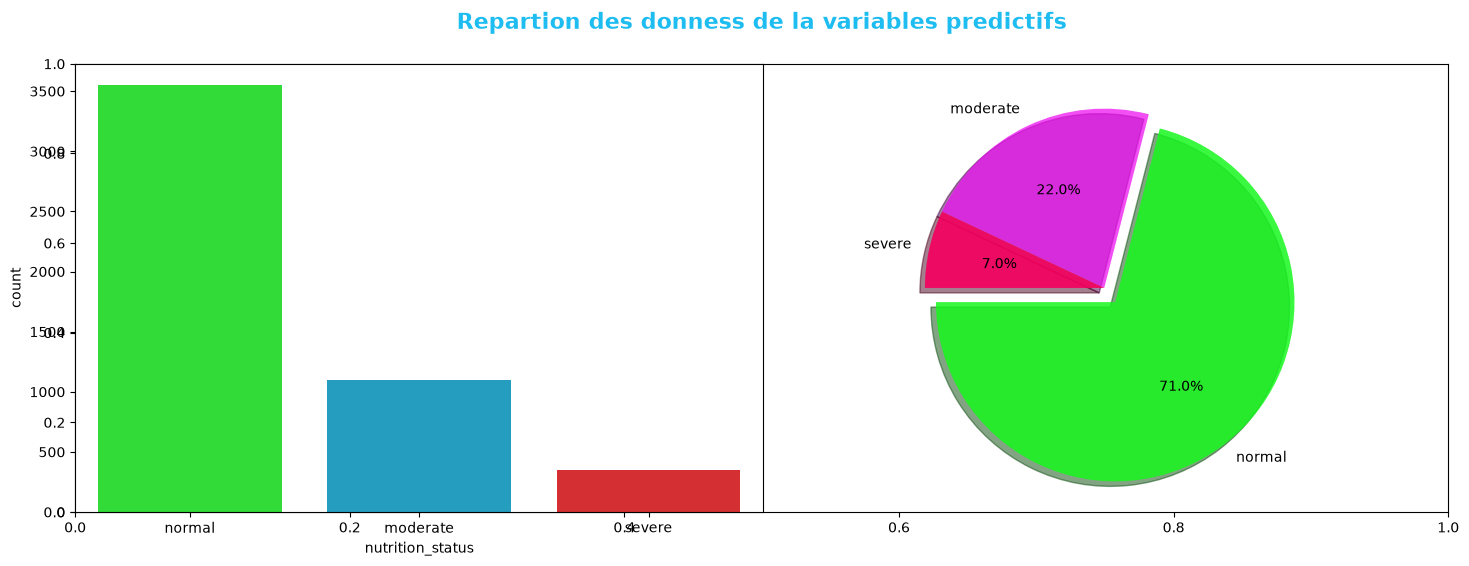

In [108]:
plt.figure(figsize = (15,6))
plt.title("Repartion des donness de la variables predictifs\n",weight = "bold", size = 16, c = "#0DB7F0EE")
plt.subplot(1,2,1)
sns.countplot(data = data,  x= "nutrition_status", palette = ["#17F71F21", "#0BACD921", "#F0131721"])
plt.subplot(1,2,2)
comptage = data["nutrition_status"].value_counts()
plt.pie(
    x = comptage, 
    labels= comptage.index, 
    autopct= "%1.1f%%", 
    startangle= 180, #Faire tourner le cercle de 180 degre 
    colors= ["#17F71ED9", "#EC0DF0BA", "#F4005EEA"],
    shadow=  True,  #Position 3d
    explode= (0.1, 0,0) #Decoupe lapartie 1
)
plt.tight_layout()
# plt.savefig("Repartition_Variables_Predictifs.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [109]:
# Nos donnees sont desequilibres

In [110]:
feature = data.select_dtypes(include ="float")
cat_feature = data.select_dtypes(include = "object")

C:\Users\dc\AppData\Local\Temp\ipykernel_21968\3165787018.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_feature = data.select_dtypes(include = "object")


In [111]:
colonne = feature.columns.tolist()
colonne

['age_months', 'weight_kg', 'height_cm', 'muac_cm', 'bmi']

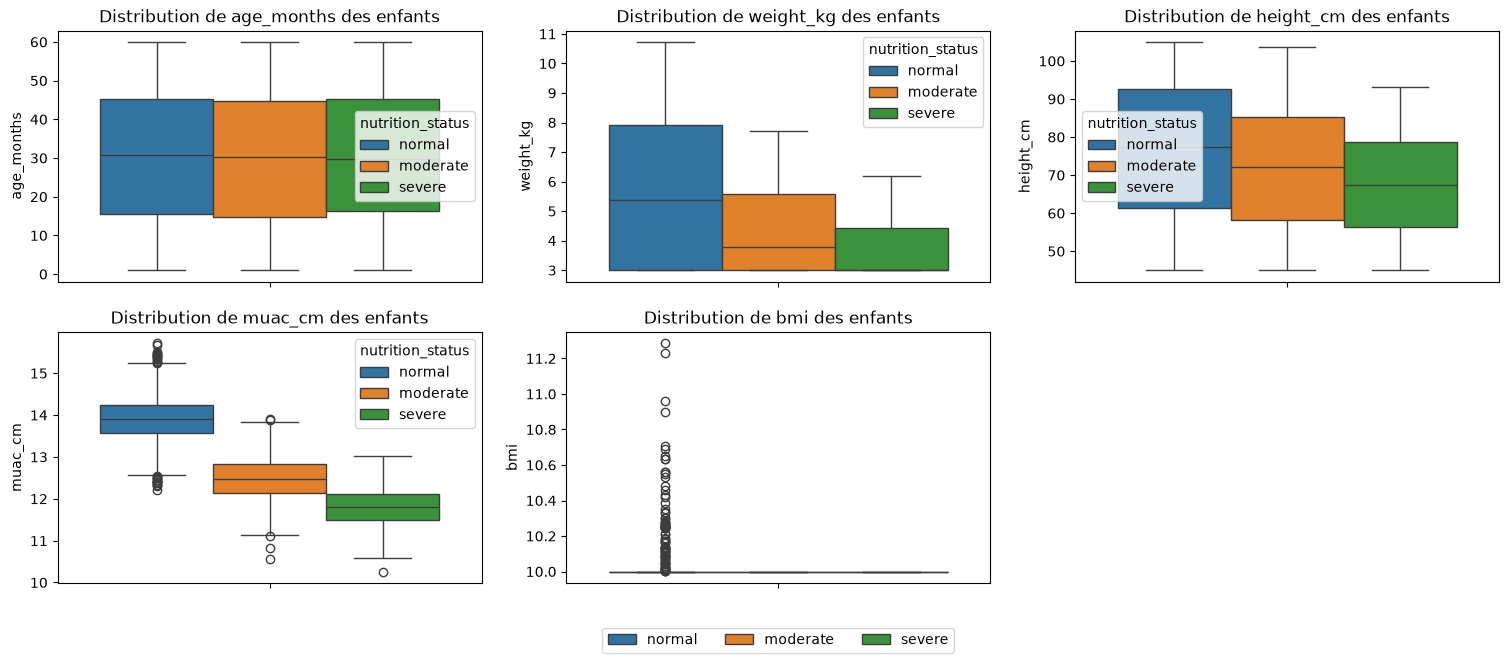

In [112]:
plt.figure(figsize= (18.6, 15))
for i in range(len(colonne)):
    plt.subplot(4, 3, i+1)
    plt.title(f"Distribution de {colonne[i]} des enfants")
    sns.boxplot(data = data, y = colonne[i], hue= "nutrition_status",)
plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3)
# plt.savefig("Box_plot_De_Toutes_Variables.png", dpi = 300, bbox_inches = "tight")

In [113]:
encode = LabelEncoder()
for i in cat_feature:
    data[i] = encode.fit_transform(data[i])

In [114]:
data.head()

,age_months,weight_kg,height_cm,muac_cm,bmi,nutrition_status
0,12.345052,3.000000,54.134002,13.160919,10.0,1
1,30.807200,5.459076,76.199180,13.944380,10.0,1
2,15.723226,3.000000,60.280820,13.243565,10.0,1
3,57.796256,10.103074,104.990471,14.105683,10.0,1
4,40.321320,7.110583,85.277902,14.641630,10.0,1


<Axes: >

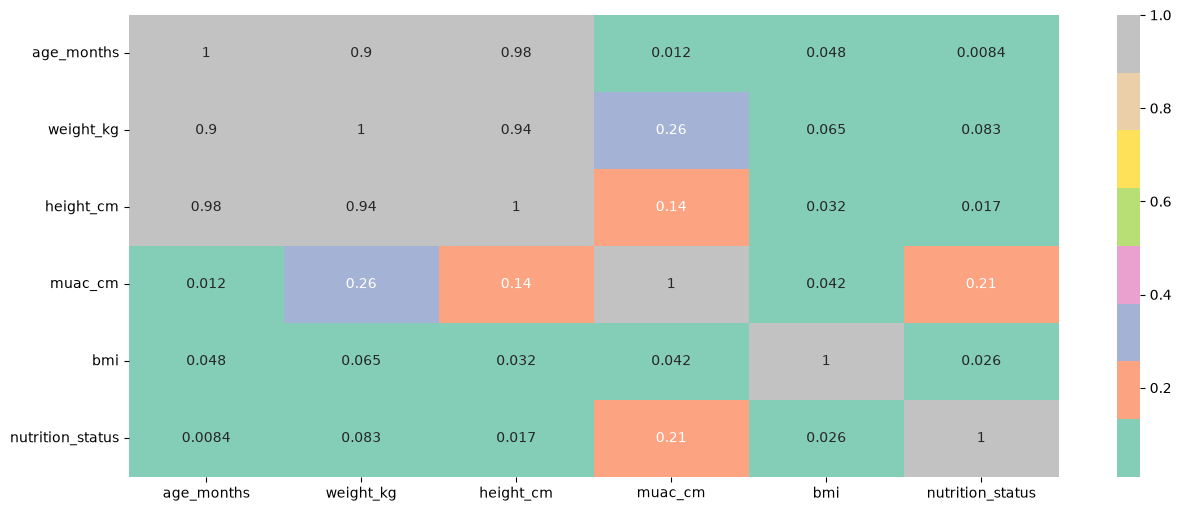

In [115]:
plt.figure(figsize=(15, 6))
sns.heatmap(data.corr(numeric_only=True), annot = True, cmap ="Set2", alpha = 0.8)
# plt.savefig("Graphique_Correlation_Des_Variables.png", dpi = 300, bbox_inches = "tight")

In [116]:
X = data.drop(columns="nutrition_status")
y = data["nutrition_status"]

In [117]:
X

,age_months,weight_kg,height_cm,muac_cm,bmi
0,12.345052,3.000000,54.134002,13.160919,10.0
1,30.807200,5.459076,76.199180,13.944380,10.0
2,15.723226,3.000000,60.280820,13.243565,10.0
3,57.796256,10.103074,104.990471,14.105683,10.0
4,40.321320,7.110583,85.277902,14.641630,10.0
...,...,...,...,...,...
4995,36.397569,4.674426,79.668509,12.976748,10.0
4996,18.947724,3.371817,62.914947,13.806374,10.0
4997,37.636794,4.504413,77.793425,12.449221,10.0
4998,27.286957,4.799405,75.048627,14.152550,10.0


In [118]:
y

0       1
1       1
2       1
3       1
4       1
       ..
4995    0
4996    1
4997    0
4998    1
4999    2
Name: nutrition_status, Length: 5000, dtype: int64

In [119]:
#Decoupage du dataset 

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 42, test_size= 0.2)

In [120]:
print(f"- Entrainement :{X_train.shape}\n- Evaluation {X_test.shape}")

- Entrainement :(4000, 5)
- Evaluation (1000, 5)


In [121]:
##Essayosn de standardiser les donnes pour avant d'entrainer notre modl KNN

scale  = StandardScaler()
X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)

 ### - 1 Modele KNN

In [122]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)
model_knn.score(X_train, y_train)

0.9655

Le score sur les donnees d'entrainment est `96 %`

In [123]:
#Entrainment sur les donnes de validation

val_score = cross_val_score(KNeighborsClassifier(), X_train, y_train, cv = 5)

In [124]:
val_score

array([0.945  , 0.94875, 0.94625, 0.96125, 0.9475 ])

In [125]:
val_score = val_score.mean()
val_score  #Pa de overfitting ou under c'est miexu mais le model a perdui un peu de sa performace 

np.float64(0.9497500000000001)

In [126]:
rang = np.arange(1, 50)
train_score, val_score  = validation_curve(
    model_knn,
    X_train, y_train,
    param_name= "n_neighbors",
    param_range= rang,
    cv =  5
)

In [127]:
moy_train = train_score.mean(axis = 1)

In [128]:
moy_train

array([1.       , 0.9720625, 0.97075  , 0.9636875, 0.964    , 0.9595625,
       0.961    , 0.958625 , 0.9579375, 0.9546875, 0.9558125, 0.9545625,
       0.9546875, 0.952875 , 0.953125 , 0.95175  , 0.952375 , 0.95075  ,
       0.9495625, 0.947625 , 0.94725  , 0.9456875, 0.945375 , 0.9444375,
       0.9440625, 0.942625 , 0.9429375, 0.941375 , 0.9406875, 0.9395625,
       0.9396875, 0.9380625, 0.938125 , 0.9370625, 0.937    , 0.9355625,
       0.93575  , 0.935125 , 0.934625 , 0.9338125, 0.9335   , 0.9329375,
       0.93325  , 0.93175  , 0.932375 , 0.93075  , 0.9305   , 0.9291875,
       0.9293125])

In [129]:
moy_val = val_score.mean(axis = 1)
moy_val

array([0.94425, 0.94075, 0.94875, 0.947  , 0.94975, 0.94825, 0.94975,
       0.94825, 0.94825, 0.947  , 0.947  , 0.94575, 0.9465 , 0.94675,
       0.94375, 0.944  , 0.94425, 0.9435 , 0.9445 , 0.944  , 0.9435 ,
       0.94225, 0.94125, 0.94025, 0.94025, 0.93825, 0.938  , 0.9365 ,
       0.93575, 0.9345 , 0.934  , 0.93325, 0.93325, 0.9315 , 0.9315 ,
       0.9305 , 0.92975, 0.92875, 0.929  , 0.927  , 0.92675, 0.927  ,
       0.92675, 0.9255 , 0.92575, 0.92625, 0.92525, 0.925  , 0.92475])

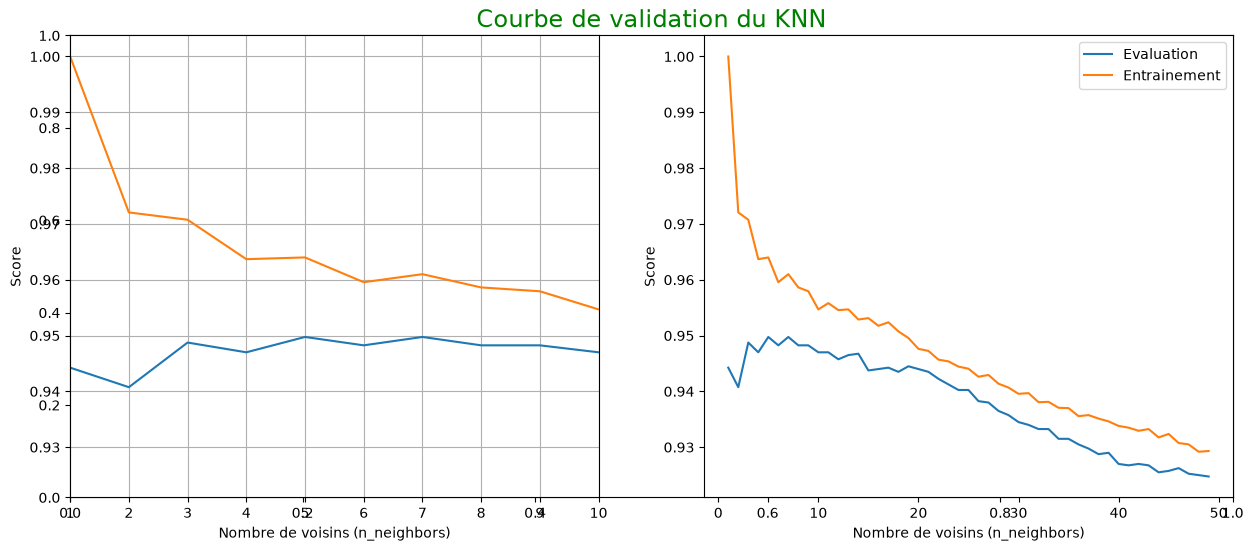

In [130]:
plt.figure(figsize= (15, 6))
plt.title("Courbe de validation du KNN", c = "green", size = 17)

plt.subplot(1,2,1)
plt.plot(rang, moy_val,  label = "Evaluation")
plt.plot(rang, moy_train,  label = "Entrainement")
plt.xlim(1,10)
plt.grid()
plt.xlabel("Nombre de voisins (n_neighbors)")
plt.ylabel("Score")

plt.subplot(1,2,2)
plt.plot(rang, moy_val,  label = "Evaluation")
plt.plot(rang, moy_train,  label = "Entrainement")

plt.xlabel("Nombre de voisins (n_neighbors)")
plt.ylabel("Score")
plt.legend()
# plt.savefig("Courbe_Validation_KNN.png", dpi = 300, bbox_inches = "tight")

In [133]:
param_grid = {
    "n_neighbors" : [2,4,5,6],
    "weights" : ["uniform", "distance"],
    "metric" : ["manhattan", "ecludean", "minkowski"]
}

grid = GridSearchCV(
    estimator= model_knn,
    param_grid = param_grid,
    n_jobs = None,
    scoring = "accuracy",
    cv = 5
)


In [134]:
grid.fit(X_train, y_train)

C:\Users\dc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
40 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\dc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\dc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Pyt

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['manhattan', 'ecludean', ...], 'n_neighbors': [2, 4, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, d

In [135]:
param = grid.best_params_
pd.DataFrame([param])

#Meilleur parametre du model KNN 

,metric,n_neighbors,weights
0,manhattan,6,distance


In [136]:
print(f"Meilleur score du model KNN: {grid.best_score_*100} %")

Meilleur score du model KNN: 95.075 %


In [137]:
KNN_best = grid.best_estimator_

In [138]:
#Visipn des erreur de prediction du modele 

confusion_matrix(y_test, KNN_best.predict(X_test))

array([[179,   8,  11],
       [  9, 725,   0],
       [ 19,   0,  49]])

In [139]:
train_sizes, train_score, val_score = learning_curve(KNN_best, X_train, y_train, train_sizes=np.linspace(0.1, 1.0,100), cv = 5 )

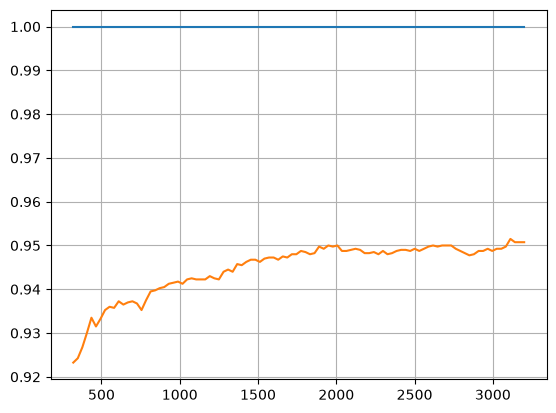

In [140]:
plt.plot(train_sizes, train_score.mean(axis = 1))
plt.plot(train_sizes, val_score.mean(axis = 1))
plt.grid()

In [141]:
y_pred = KNN_best.predict(X_test)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.3f}")
print(f"F1 Score  : {f1_score(y_test, y_pred, average = 'weighted'):.3f}")

Accuracy  : 0.953
F1 Score  : 0.953


In [142]:
metrique = classification_report(y_test, y_pred, output_dict = True)
pd.DataFrame(metrique).transpose().round(3)

,precision,recall,f1-score,support
0,0.865,0.904,0.884,198.000
1,0.989,0.988,0.988,734.000
2,0.817,0.721,0.766,68.000
accuracy,0.953,0.953,0.953,0.953
macro avg,0.890,0.871,0.879,1000.000
weighted avg,0.953,0.953,0.953,1000.000


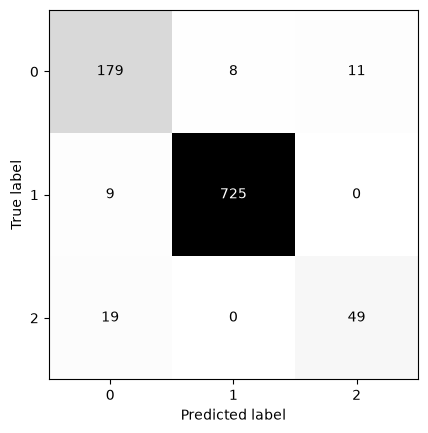

In [143]:
matrice = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=KNN_best.classes_)
matrice.plot(cmap = "Greys", colorbar = False)
# plt.savefig("Matrice_Confusion_KNN.png" ,dpi = 300, bbox_inches = "tight")

## Model Decision Tree

In [144]:
model_ABR = DecisionTreeClassifier() #Initialisation du model de DecisionTreeClassifier

In [145]:
model_ABR.fit(X_train, y_train)
print(f"\nScore du model ABR sur les données d'entraînement : {model_ABR.score(X_train, y_train)}")


Score du model ABR sur les données d'entraînement : 1.0


In [146]:
val_score_ABR = cross_val_score(model_ABR, X_train, y_train, cv = 5)
print(f"\nScore de validation  ABR : {val_score_ABR}")
print(f"\nScore de validation croisée du model ABR : {val_score_ABR.mean()}")


Score de validation  ABR : [0.91375 0.9075  0.90125 0.915   0.9125 ]

Score de validation croisée du model ABR : 0.9099999999999999


In [147]:
train_score , val_score = validation_curve(model_ABR, X_train, y_train, param_name= "max_depth",param_range= np.arange(1, 50), cv = 5 )

In [148]:
train_score.mean(axis = 1)

array([0.870375 , 0.8811875, 0.8911875, 0.902625 , 0.90825  , 0.927125 ,
       0.9354375, 0.944375 , 0.95275  , 0.9595   , 0.967125 , 0.9729375,
       0.9794375, 0.9849375, 0.989375 , 0.9925   , 0.99525  , 0.9964375,
       0.99775  , 0.9986875, 0.9990625, 0.99925  , 0.9996875, 0.999625 ,
       1.       , 0.999875 , 0.9999375, 0.9999375, 1.       , 1.       ,
       1.       , 1.       , 1.       , 1.       , 1.       , 1.       ,
       1.       , 1.       , 1.       , 1.       , 1.       , 1.       ,
       1.       , 1.       , 1.       , 1.       , 1.       , 1.       ,
       1.       ])

In [149]:
val_score.mean(axis = 1)

array([0.86925, 0.8785 , 0.887  , 0.89325, 0.89725, 0.9095 , 0.90925,
       0.9135 , 0.9175 , 0.91375, 0.917  , 0.91375, 0.91625, 0.916  ,
       0.91425, 0.91375, 0.91525, 0.91675, 0.9125 , 0.91375, 0.91225,
       0.91475, 0.91175, 0.91175, 0.913  , 0.9135 , 0.91325, 0.91275,
       0.91175, 0.9115 , 0.91275, 0.91125, 0.91375, 0.91325, 0.9135 ,
       0.9125 , 0.91425, 0.91225, 0.91125, 0.914  , 0.913  , 0.9125 ,
       0.91475, 0.912  , 0.9105 , 0.91125, 0.91425, 0.91275, 0.91275])

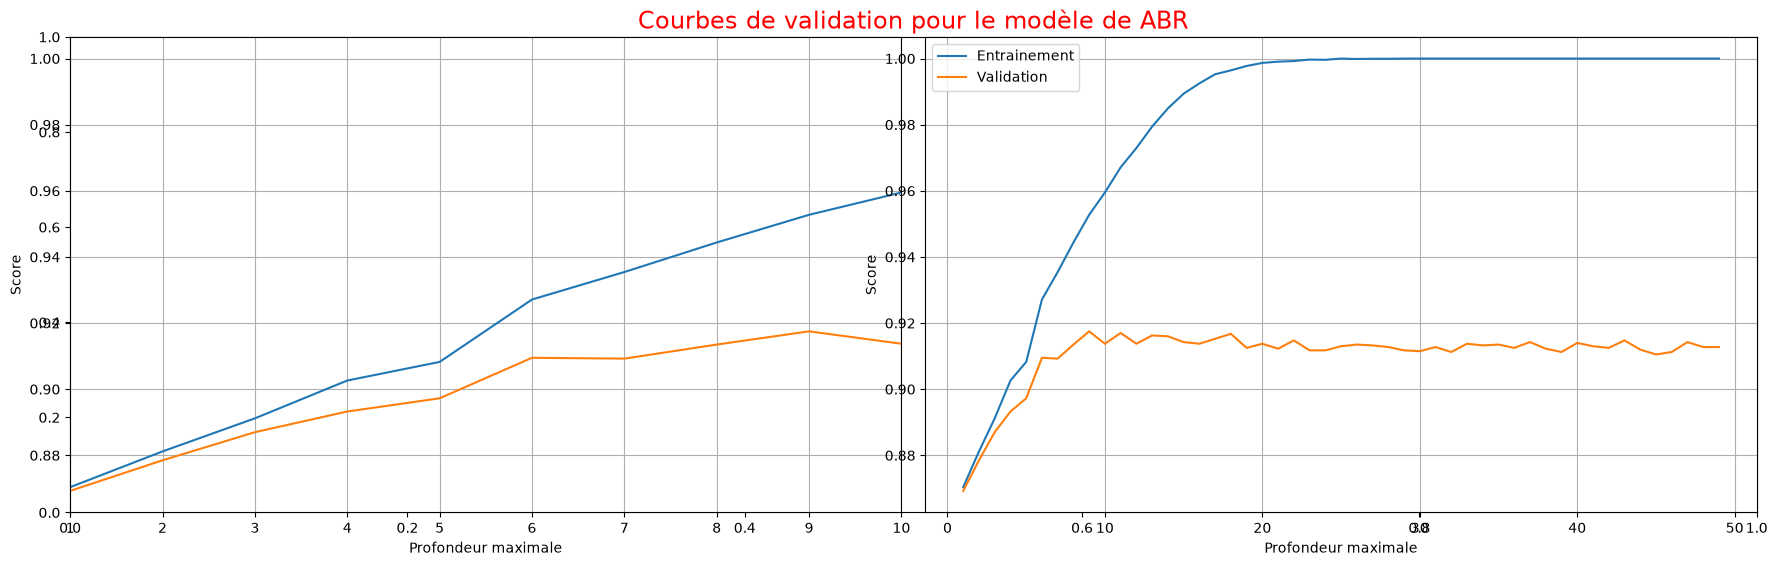

In [150]:
plt.figure(figsize= (18, 6))
plt.title("Courbes de validation pour le modèle de ABR", size = 17 , c= 'red')
plt.subplot(1,2,1)
plt.plot(np.arange(1, 50), train_score.mean(axis = 1), label = "Entrainement")
plt.plot(np.arange(1, 50), val_score.mean(axis = 1), label = "Validation")
plt.grid(True)
plt.xlim(1, 10)
plt.xlabel("Profondeur maximale")
plt.tight_layout()
plt.ylabel("Score")

plt.subplot(1,2,2)
plt.plot(np.arange(1, 50), train_score.mean(axis = 1), label = "Entrainement")
plt.plot(np.arange(1, 50), val_score.mean(axis = 1), label = "Validation")
plt.grid()
plt.xlabel("Profondeur maximale")
plt.ylabel("Score")

plt.legend()
# plt.savefig("Courbe_Validation_Modele_Decision_Tree.png", bbox_inches = "tight", dpi = 300)
plt.show()

- de ce que je vois graphiquement le model de ABR donne un meilleur score pour une profonduer maximum = 9, pour un score compris entre [0.90, 0.92]

In [154]:
## Detemination du meilleeur estimateur 

param_grid = {
    "max_depth" : [7, 9, 10],
    "min_samples_split" : [2,5,6,7,10],
    "criterion"  :["gini", "entropy"]
}

In [160]:
grid_abr  = GridSearchCV(
    estimator = model_ABR, 
    param_grid = param_grid, 
    n_jobs = None,
    scoring = "recall_macro",
    cv = 5,
    verbose = 2
)

In [161]:
grid_abr.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END ...criterion=gini, max_depth=7, min_samples_split=2; total time=   0.0s
[CV] END ...criterion=gini, max_depth=7, min_samples_split=2; total time=   0.0s
[CV] END ...criterion=gini, max_depth=7, min_samples_split=2; total time=   0.0s
[CV] END ...criterion=gini, max_depth=7, min_samples_split=2; total time=   0.0s
[CV] END ...criterion=gini, max_depth=7, min_samples_split=2; total time=   0.0s
[CV] END ...criterion=gini, max_depth=7, min_samples_split=5; total time=   0.0s
[CV] END ...criterion=gini, max_depth=7, min_samples_split=5; total time=   0.0s
[CV] END ...criterion=gini, max_depth=7, min_samples_split=5; total time=   0.0s
[CV] END ...criterion=gini, max_depth=7, min_samples_split=5; total time=   0.0s
[CV] END ...criterion=gini, max_depth=7, min_samples_split=5; total time=   0.0s
[CV] END ...criterion=gini, max_depth=7, min_samples_split=6; total time=   0.0s
[CV] END ...criterion=gini, max_depth=7, min_sa

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [7, 9, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot

In [162]:
print(f"Meilleurt score : {grid_abr.best_score_}\nparamètres optimaux : {grid_abr.best_params_}")

Meilleurt score : 0.8144245273305046
paramètres optimaux : {'criterion': 'entropy', 'max_depth': 9, 'min_samples_split': 5}


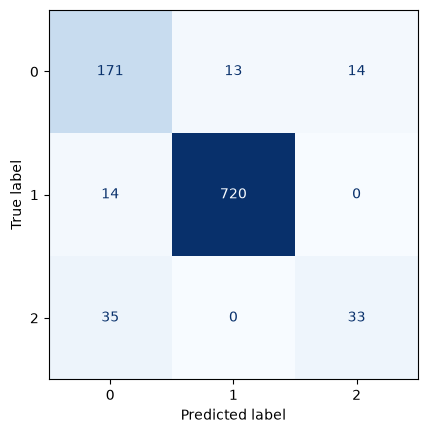

In [163]:
#Matrice de confusion du model ABR
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, grid_abr.predict(X_test)),
    display_labels=grid_abr.classes_).plot(cmap = "Blues", colorbar = False)
# plt.savefig("Matrice_Confusion_ARBRE_DCESION.png", dpi = 300, bbox_inches = "tight")

In [164]:
rapport = classification_report(y_test, grid_abr.predict(X_test), output_dict = True)
pd.DataFrame(rapport).transpose().round(3)

,precision,recall,f1-score,support
0,0.777,0.864,0.818,198.000
1,0.982,0.981,0.982,734.000
2,0.702,0.485,0.574,68.000
accuracy,0.924,0.924,0.924,0.924
macro avg,0.821,0.777,0.791,1000.000
weighted avg,0.923,0.924,0.922,1000.000


In [165]:
grid_abr.score(X_test, y_test)  # Scorre sur les donnees de test

0.7766189706003779

### Random Forest 

In [166]:

model_RF = RandomForestClassifier() #Initialisation du model de RandomForestClassifier

In [167]:
model_RF.fit(X_train, y_train)
model_RF.score(X_train, y_train)

1.0

In [168]:
val_score = cross_val_score(model_RF, X_train, y_train , cv = 5)
val_score

array([0.9375 , 0.93875, 0.94625, 0.96125, 0.935  ])

In [169]:
val_score.mean( ) #Moyenne des score de la validation

np.float64(0.94375)

In [170]:
train_score, val_score = validation_curve(
    model_RF,
    X_train,
    y_train , 
    param_name= "max_depth", 
    param_range=np.arange(1, 50),
    cv = 5
)

In [171]:
train_score.mean(axis = 1) ##Score entrainement 

array([0.80475  , 0.8778125, 0.8820625, 0.905875 , 0.9190625, 0.92925  ,
       0.936125 , 0.94475  , 0.95425  , 0.9614375, 0.970125 , 0.97675  ,
       0.981625 , 0.98675  , 0.9913125, 0.9944375, 0.996625 , 0.9975625,
       0.999    , 0.999625 , 0.9999375, 1.       , 1.       , 1.       ,
       1.       , 1.       , 1.       , 1.       , 1.       , 1.       ,
       1.       , 1.       , 1.       , 1.       , 1.       , 1.       ,
       1.       , 0.9999375, 1.       , 1.       , 1.       , 1.       ,
       1.       , 1.       , 1.       , 1.       , 1.       , 0.9999375,
       1.       ])

In [172]:
val_score.mean(axis= 1) #Score validationn 

array([0.80125, 0.87525, 0.878  , 0.8965 , 0.90975, 0.91675, 0.92225,
       0.92725, 0.93   , 0.93275, 0.939  , 0.942  , 0.942  , 0.946  ,
       0.9445 , 0.94425, 0.94425, 0.94525, 0.9455 , 0.94375, 0.944  ,
       0.94325, 0.94325, 0.94475, 0.944  , 0.94375, 0.946  , 0.94425,
       0.942  , 0.94625, 0.944  , 0.944  , 0.9445 , 0.945  , 0.94525,
       0.94475, 0.94575, 0.945  , 0.9455 , 0.94425, 0.94475, 0.94275,
       0.94325, 0.94375, 0.94675, 0.94275, 0.94425, 0.94575, 0.943  ])

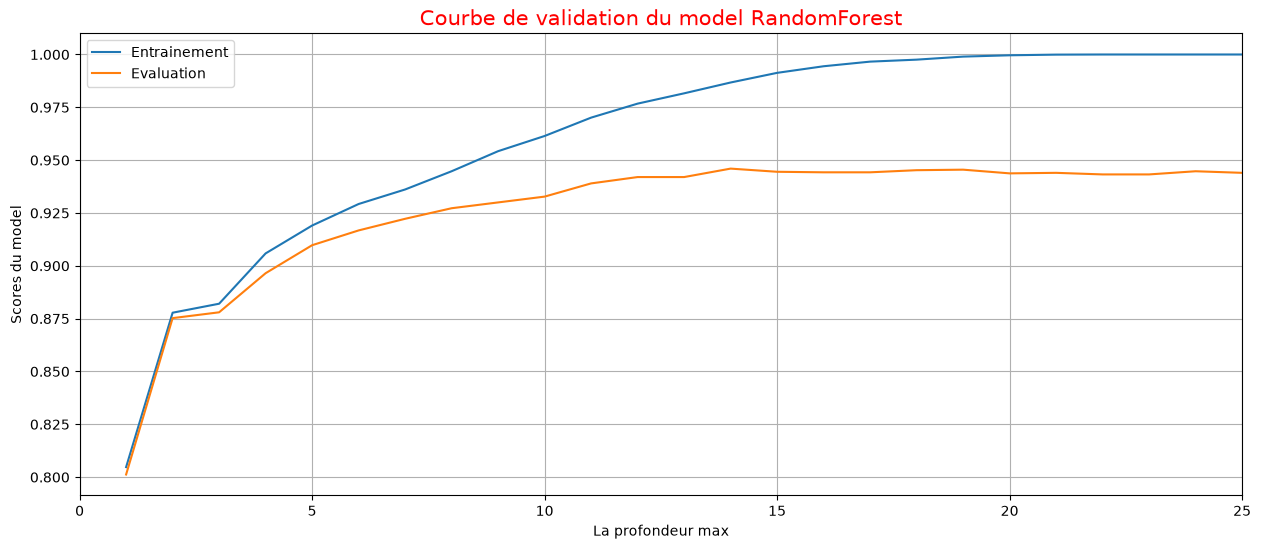

In [173]:
plt.figure(figsize= (15, 6))
plt.title("Courbe de validation du model RandomForest", c = "red", size = 15)
k = np.arange(1, 50)
plt.plot(k, train_score.mean(axis = 1), label = "Entrainement")
plt.plot(k, val_score.mean(axis = 1), label = "Evaluation ")
plt.xlabel("La profondeur max")
plt.ylabel("Scores du model")
plt.grid()
plt.xlim(0, 25)
plt.legend()
# plt.savefig("Courbe_Validation_RANDOM_FOREST.png", dpi = 300, bbox_inches = "tight")

In [174]:
## Recherche du meilleeur modeles avec les meilleur hyperparametresz
parametres = {
    "max_depth": [10,14, 20],
    "n_estimators" : [100, 200],
    "max_features" : ["sqrt"],
    "class_weight" : ["balanced"],
    "criterion" : ["gini"]
}

grid_RF = GridSearchCV(
    estimator= model_RF,
    param_grid= parametres,
    scoring= "accuracy",
    n_jobs =None,
    verbose = 2 , #barvard (details technique en temps reels)
    cv = 5
)

In [175]:
grid_RF.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END class_weight=balanced, criterion=gini, max_depth=10, max_features=sqrt, n_estimators=100; total time=   1.2s
[CV] END class_weight=balanced, criterion=gini, max_depth=10, max_features=sqrt, n_estimators=100; total time=   1.5s
[CV] END class_weight=balanced, criterion=gini, max_depth=10, max_features=sqrt, n_estimators=100; total time=   0.9s
[CV] END class_weight=balanced, criterion=gini, max_depth=10, max_features=sqrt, n_estimators=100; total time=   1.1s
[CV] END class_weight=balanced, criterion=gini, max_depth=10, max_features=sqrt, n_estimators=100; total time=   1.0s
[CV] END class_weight=balanced, criterion=gini, max_depth=10, max_features=sqrt, n_estimators=200; total time=   2.6s
[CV] END class_weight=balanced, criterion=gini, max_depth=10, max_features=sqrt, n_estimators=200; total time=   2.1s
[CV] END class_weight=balanced, criterion=gini, max_depth=10, max_features=sqrt, n_estimators=200; total time=   2

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'criterion': ['gini'], 'max_depth': [10, 14, ...], 'max_features': ['sqrt'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_

In [176]:
df = pd.DataFrame([grid_RF.best_params_])
print(f"\n- Le meilleur score  {grid_RF.best_score_}")


- Le meilleur score  0.9417500000000001


In [177]:
df.T##  meilleur hyperparametres du models 

,0
class_weight,balanced
criterion,gini
max_depth,20
max_features,sqrt
n_estimators,100


In [178]:
best_RF = grid_RF.best_estimator_
y_pred = best_RF.predict(X_test)

In [179]:
#Analyse des metriques 
rapport = classification_report(y_test, y_pred, output_dict= True)
df_rapport= pd.DataFrame(rapport).T
df_rapport = df_rapport.round(2)
df_rapport

,precision,recall,f1-score,support
0,0.85,0.89,0.87,198.00
1,0.99,0.97,0.98,734.00
2,0.78,0.82,0.80,68.00
accuracy,0.95,0.95,0.95,0.95
macro avg,0.87,0.90,0.88,1000.00
weighted avg,0.95,0.95,0.95,1000.00


In [180]:
confusion_matrix(y_test, y_pred)

array([[176,   6,  16],
       [ 20, 714,   0],
       [ 12,   0,  56]])

Text(0.5, 1.0, 'Matrice_Confusion_RandomForest')

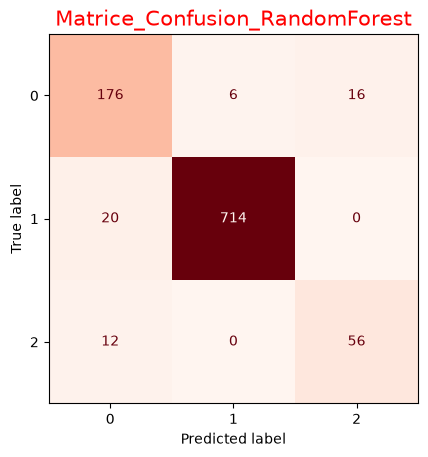

In [181]:

ax = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels= grid_RF.classes_
).plot(cmap = "Reds" ,colorbar= False)
plt.title("Matrice_Confusion_RandomForest", c = "red", size = 15)
# plt.savefig("Matrice_Confusion_RandomForest.png", dpi = 300, bbox_inches = "tight")

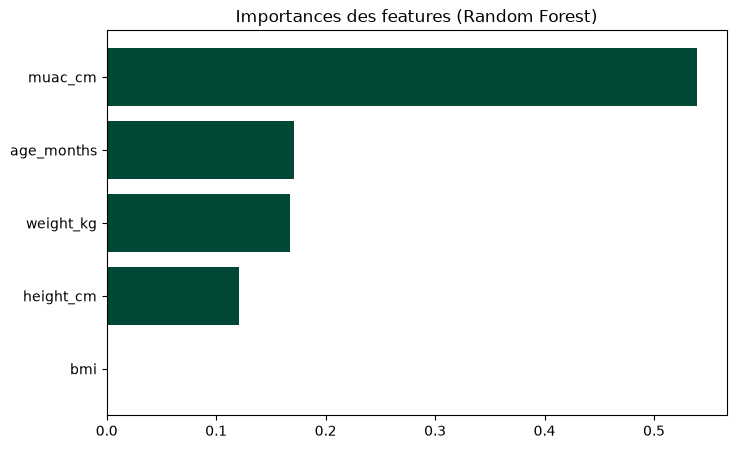

In [182]:
# Visualisation de l'importance de chaque variables
importances = grid_RF.best_estimator_.feature_importances_
feat_names = ["age_months", "weight_kg", "height_cm", "muac_cm", "bmi"]
indices = importances.argsort()[::-1]
plt.figure(figsize=(8,5))
plt.title("Importances des features (Random Forest)")
plt.barh(range(len(indices)), importances[indices], align='center', color = ["#004735"])
plt.yticks(range(len(indices)), [feat_names[i] for i in indices])
plt.gca().invert_yaxis()
# plt.savefig("Graphique_Importances_Des_Variables_explicatives.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [183]:
#application du smote sur les donnee d'entrainement
smoter = SMOTE(random_state= 42)
X_train_smote, y_train_smote = smoter.fit_resample(X_train, y_train)

In [184]:

pd.Series(y_train_smote).value_counts() #Les classes sont maintenant equilibres

nutrition_status
1    2816
0    2816
2    2816
Name: count, dtype: int64

In [185]:
# Entrainement du model sur les donnees augementer

RF_smote = RandomForestClassifier(
    random_state= 42,
    max_depth= 20,
    max_features=  "sqrt",
    n_jobs= None,
    criterion= "gini",
    # verbose= 2
)

In [186]:
RF_smote.fit(X_train_smote, y_train_smote)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [187]:
k = np.arange(1,30)
train_score_smote , val_score_smote = validation_curve(
    RF_smote,
    X_train_smote,
    y_train_smote,
    scoring= "recall_macro", #Optimisation du rappelle des classe minoritaires
    param_range= k,
    param_name= "max_depth",
    cv = 5
)

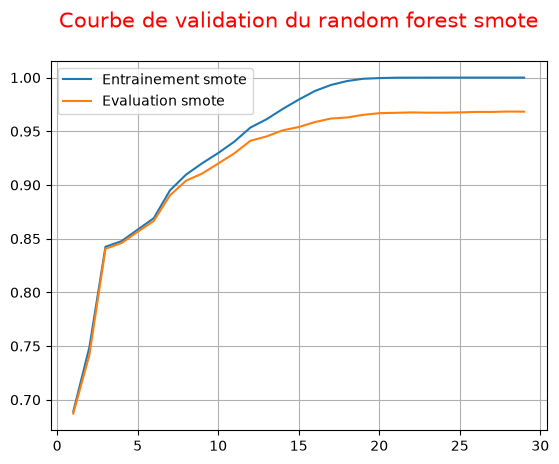

In [188]:
plt.title(f"Courbe de validation du random forest smote\n",c = "red", size = 15)
plt.plot(k, train_score_smote.mean(axis = 1), label = "Entrainement smote")
plt.plot(k, val_score_smote.mean(axis = 1), label = "Evaluation smote")
plt.grid()
plt.legend()
# plt.savefig("Courbe_Validation_RANDOM_FOREST_SMOTE.png", dpi =300, bbox_inches = "tight")

In [189]:
RF_smote.score(X_train_smote, y_train_smote) #Score sur les donnes de l'entrainement

0.9995265151515151

In [193]:
#Recherche du meilleur estimateur smote
param_grid = {
    "n_estimators" : [200, 300, 400],
    "max_depth"   : [19, 20, 21, 29],
    "criterion"   : ["entropy"]
} 

smote_grid = GridSearchCV(
    estimator= RF_smote,
    param_grid= param_grid,
    n_jobs= None,
    scoring= "recall_macro",
    verbose = 2,
    cv = 5
)  

In [194]:
smote_grid.fit(X_train_smote, y_train_smote)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


[CV] END ..criterion=entropy, max_depth=19, n_estimators=200; total time=   7.0s
[CV] END ..criterion=entropy, max_depth=19, n_estimators=200; total time=   7.7s
[CV] END ..criterion=entropy, max_depth=19, n_estimators=200; total time=   7.6s
[CV] END ..criterion=entropy, max_depth=19, n_estimators=200; total time=   7.3s
[CV] END ..criterion=entropy, max_depth=19, n_estimators=200; total time=   7.5s
[CV] END ..criterion=entropy, max_depth=19, n_estimators=300; total time=   8.8s
[CV] END ..criterion=entropy, max_depth=19, n_estimators=300; total time=  11.4s
[CV] END ..criterion=entropy, max_depth=19, n_estimators=300; total time=  10.1s
[CV] END ..criterion=entropy, max_depth=19, n_estimators=300; total time=   9.9s
[CV] END ..criterion=entropy, max_depth=19, n_estimators=300; total time=   9.9s
[CV] END ..criterion=entropy, max_depth=19, n_estimators=400; total time=  13.4s
[CV] END ..criterion=entropy, max_depth=19, n_estimators=400; total time=  12.7s
[CV] END ..criterion=entropy

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['entropy'], 'max_depth': [19, 20, ...], 'n_estimators': [200, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_

In [195]:
print(f"Meilleur score : {smote_grid.best_score_}")

Meilleur score : 0.9692236792932156


In [196]:
print("Meilleur hyperparametre")
df_parametre = pd.DataFrame([smote_grid.best_params_])
df_parametre.T

Meilleur hyperparametre


,0
criterion,entropy
max_depth,29
n_estimators,400


In [197]:
best_model_smote = smote_grid.best_estimator_

In [198]:
y_pred_smote = best_model_smote.predict(X_test)
rapport_metric = classification_report(y_test, y_pred, output_dict= True)
df_rapporte = pd.DataFrame(rapport_metric).T
df_rapporte.round(2)

,precision,recall,f1-score,support
0,0.85,0.89,0.87,198.00
1,0.99,0.97,0.98,734.00
2,0.78,0.82,0.80,68.00
accuracy,0.95,0.95,0.95,0.95
macro avg,0.87,0.90,0.88,1000.00
weighted avg,0.95,0.95,0.95,1000.00


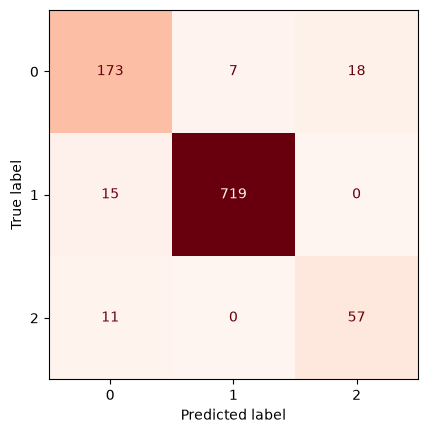

In [199]:
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_smote),
    display_labels= best_model_smote.classes_
).plot(cmap = "Reds", colorbar= False)

In [200]:
RF_smote.score(X_test, y_test)

0.948

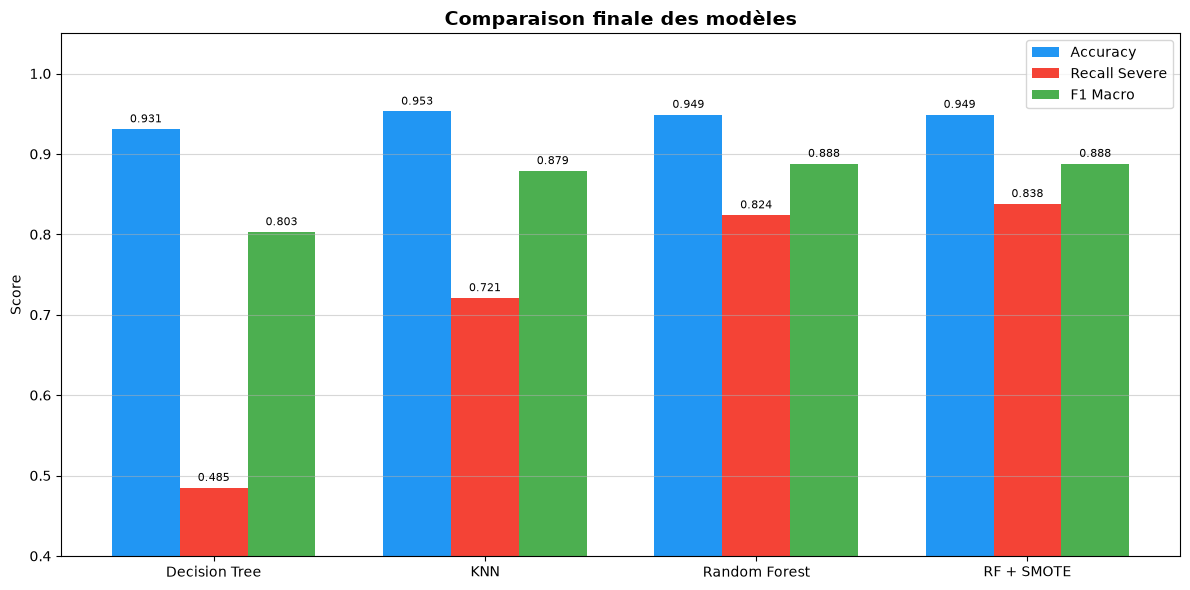

In [201]:

# Tes résultats finaux
modeles = ["Decision Tree", "KNN", "Random Forest", "RF + SMOTE"]

accuracy  = [0.931, 0.953, 0.949, 0.949]
recall_severe = [0.485, 0.721, 0.824, 0.838]
f1_macro  = [0.803, 0.879, 0.888, 0.888]

x = np.arange(len(modeles))
width = 0.25  # Largeur de chaque barre

fig, ax = plt.subplots(figsize=(12, 6))

# Les 3 groupes de barres
bars1 = ax.bar(x - width, accuracy, width, label="Accuracy", color="#2196F3")
bars2 = ax.bar(x, recall_severe, width, label="Recall Severe", color="#F44336")
bars3 = ax.bar(x + width, f1_macro, width, label="F1 Macro", color="#4CAF50")

# Afficher les valeurs sur les barres
for bar in bars1 + bars2 + bars3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8)

ax.set_title("Comparaison finale des modèles", fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modeles)
ax.set_ylim(0.4, 1.05)
ax.set_ylabel("Score")
ax.legend()
ax.grid(axis='y', alpha=0.5)

plt.tight_layout()
# plt.savefig("Graphique_Comparaison_modelèles.png", dpi = 300,bbox_inches = "tight")
plt.show()

## Conclusion finale : Choix du meilleur modèle

Sur la base de l'analyse comparative des performances, le modèle retenu est **RF + SMOTE** (Random Forest combiné à la méthode de suréchantillonnage SMOTE).

### Justification du choix

* **Optimisation de la classe critique :** Ce modèle affiche le **Recall Severe le plus élevé (0,838)**. Dans un contexte où l'identification des cas "Severe" est prioritaire, c'est le modèle qui minimise le mieux le risque de faux négatifs (le fait de rater un cas grave).
* **Excellence globale préservée :** L'application de la méthode SMOTE n'a pas dégradé les autres métriques. Le modèle maintient une **Accuracy maximale de 0,949** et un **F1 Macro de 0,888**, égalant le Random Forest classique tout en étant plus performant sur la classe cible.

---
**Verdict :** Le modèle **RF + SMOTE** offre le meilleur compromis et la plus haute sécurité pour la détection des événements critiques. C'est la solution à privilégier pour le déploiement.


In [202]:
#Verifions voir si le model est entrainer o pas 
if hasattr(RF_smote, "estimators_") or (hasattr(RF_smote, "named_steps") and hasattr(RF_smote.steps[-1][1], "estimators_")):
    print("✅ Le modele est deja entrainer dans la memoire.")
else:
    print("❌ Le modele n'est pas entrainer . a rentrainer.")


✅ Le modele est deja entrainer dans la memoire.


In [ ]:
# joblib.dump(RF_smote, "best_model.joblib", compress=3)
# print(joblib.load("best_model.joblib"))   # vérifie qu'il se recharge
# # print("Modele d enregistrer avec succes")

RandomForestClassifier(max_depth=20, random_state=42)
